<a href="https://colab.research.google.com/github/Jeevansomavarapu/ML_Project2/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:

df=pd.read_csv('hotel_bookings.csv')

In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,7/1/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,7/1/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,7/2/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,7/2/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,7/3/2015


In [6]:
type(df)

pandas.core.frame.DataFrame

In [7]:
df.shape

(36565, 32)

In [8]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [9]:
df.drop(['agent','company'],axis=1,inplace=True)

In [10]:
df['country'].value_counts().index[0]

'PRT'

In [11]:
df['country'].fillna(df['country'].value_counts().index[0],inplace=True)

/tmp/ipykernel_7395/1960897156.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna(df['country'].value_counts().index[0],inplace=True)


In [12]:
df.fillna(0,inplace=True)

In [13]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [14]:
### seems to have some dirtiness in data as Adults,babies & children cant be zero at a same time ..

### bcz if 3 entities are 0 ,then how can a booking be possible ??

In [15]:
### Visualise Entire Dataframe where adult,children & babies are 0

filter1=(df['children']==0) & (df['adults']==0) & (df['babies']==0)

In [16]:
df[filter1]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,I,1,No Deposit,0,Transient-Party,0.0,0,0,Check-Out,10/6/2015
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,I,0,No Deposit,0,Transient,0.0,0,0,Check-Out,10/12/2015
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,C,0,No Deposit,0,Transient-Party,0.0,0,0,Check-Out,11/23/2015
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,A,1,No Deposit,122,Transient-Party,0.0,0,0,Check-Out,1/4/2016
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,C,1,No Deposit,122,Transient-Party,0.0,0,0,Check-Out,1/5/2016
4127,Resort Hotel,1,0,2016,February,8,15,0,0,0,...,P,0,No Deposit,0,Transient,0.0,0,0,Canceled,2/15/2016
9376,Resort Hotel,1,0,2016,November,48,21,0,0,0,...,P,0,No Deposit,0,Group,0.0,0,0,Canceled,11/21/2016
31765,Resort Hotel,0,31,2016,December,53,27,2,8,0,...,D,3,No Deposit,0,Transient,28.0,1,0,Check-Out,1/6/2017
32029,Resort Hotel,0,4,2017,January,2,14,0,1,0,...,G,0,No Deposit,0,Transient-Party,0.0,0,0,Check-Out,1/15/2017
32827,Resort Hotel,0,46,2017,January,4,25,3,9,0,...,I,8,No Deposit,0,Transient,0.0,0,0,Check-Out,2/6/2017


In [17]:
data=df[~filter1]

In [18]:
data.shape

(36553, 30)

In [19]:
df.shape

(36565, 30)

In [20]:
df[df['children']==0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,0,Transient,0.00,0,0,Check-Out,7/1/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,0,Transient,0.00,0,0,Check-Out,7/1/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,0,Transient,75.00,0,0,Check-Out,7/2/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,0,Transient,75.00,0,0,Check-Out,7/2/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,0,Transient,98.00,0,1,Check-Out,7/3/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36560,Resort Hotel,0,11,2017,May,20,18,2,4,2,...,C,0,No Deposit,0,Transient,72.67,0,1,Check-Out,5/24/2017
36561,Resort Hotel,0,107,2017,May,20,20,2,2,2,...,A,1,No Deposit,0,Transient,47.50,0,1,Check-Out,5/24/2017
36562,Resort Hotel,0,168,2017,May,20,15,3,6,2,...,E,0,No Deposit,0,Transient,84.45,0,0,Check-Out,5/24/2017
36563,Resort Hotel,0,1,2017,May,21,23,0,1,2,...,D,0,No Deposit,0,Transient,97.00,1,1,Check-Out,5/24/2017


In [21]:
data['is_canceled'].unique()

array([0, 1])

In [22]:
data[data['is_canceled']==0]['country'].value_counts()/75011

,count
country,
PRT,0.129488
GBR,0.067843
ESP,0.036341
IRL,0.019837
FRA,0.017038
...,...
QAT,0.000013
MDG,0.000013
UZB,0.000013


In [23]:
len(data[data['is_canceled']==0])

25434

In [24]:
country_wise_data=data[data['is_canceled']==0]['country'].value_counts().reset_index()
country_wise_data.columns=['country','no_of_guests']
country_wise_data

,country,no_of_guests
0,PRT,9713
1,GBR,5089
2,ESP,2726
3,IRL,1488
4,FRA,1278
...,...,...
106,QAT,1
107,MDG,1
108,UZB,1
109,NPL,1


In [26]:
!pip install chart-studio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.5 MB/s eta 0:00:00


In [27]:
import plotly
import chart_studio.plotly as py
from plotly.offline import download_plotlyjs ,init_notebook_mode ,plot ,iplot
init_notebook_mode(connected=True)

In [ ]:
!pip install chart-studio

In [28]:
import plotly.express as px

In [29]:
map_guest=px.choropleth(country_wise_data,
             locations=country_wise_data['country'],
             color=country_wise_data['no_of_guests'],
              hover_name=country_wise_data['country'],
              title='home country of guests'
             )

In [30]:
map_guest.show()

In [31]:
data2=data[data['is_canceled']==0]

In [32]:
data2.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

Text(0, 0.5, 'price( EUR)')

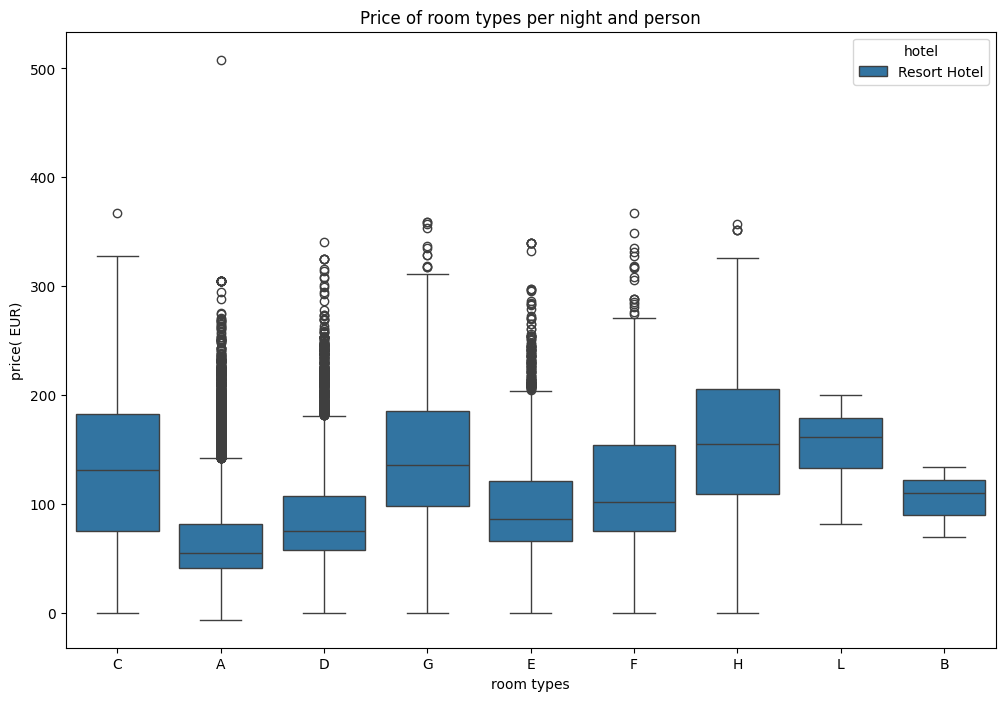

In [33]:
# seaborn boxplot:

plt.figure(figsize=(12,8))
sns.boxplot(x='reserved_room_type',y='adr' ,hue='hotel',data=data2)

plt.title('Price of room types per night and person')
plt.xlabel('room types')
plt.ylabel('price( EUR)')

In [34]:
data['hotel'].unique()

array(['Resort Hotel'], dtype=object)

In [35]:

data_resort=data[(data['hotel']=='Resort Hotel') & (data['is_canceled']==0)]
data_city = data[(data['hotel']=='City Hotel') & (data['is_canceled']==0)]

In [36]:
rush_resort=data_resort['arrival_date_month'].value_counts().reset_index()
rush_resort.columns=['month','no_of_guests']
rush_resort

,month,no_of_guests
0,October,2575
1,March,2571
2,April,2550
3,February,2308
4,August,2208
5,July,2107
6,September,2102
7,May,2078
8,December,2014
9,November,1975


In [37]:
rush_city=data_city['arrival_date_month'].value_counts().reset_index()
rush_city.columns=['month','no_of_guests']
rush_city

,month,no_of_guests


In [38]:
final_rush=rush_resort.merge(rush_city,on='month')

In [39]:
final_rush.columns=['month','no_of_guests_in_resort','no_of_guests_city']

In [40]:
final_rush

,month,no_of_guests_in_resort,no_of_guests_city


In [41]:
!pip install sorted-months-weekdays

## Dependency package needs to be installed
!pip install sort_dataframeby_monthorweek

  Preparing metadata (setup.py) ... done
  Created wheel for sorted-months-weekdays: filename=sorted_months_weekdays-0.2-py3-none-any.whl size=3225 sha256=94ee97d1fc5546d0cf4eaa8a4256bb8f1e5dcc6a84948b2c0dc0690b2dc9e70a
  Stored in directory: /root/.cache/pip/wheels/54/e3/35/69154f792680024da16cabf0a8e4ac1052f3db0f22401ccf7a
Successfully built sorted-months-weekdays
  Preparing metadata (setup.py) ... done
  Created wheel for sort_dataframeby_monthorweek: filename=sort_dataframeby_monthorweek-0.4-py3-none-any.whl size=3419 sha256=5a1d99cabc3d420c9ba899af71c1e9481c8f417b72817df97da15df0bd30581c
  Stored in directory: /root/.cache/pip/wheels/17/94/f3/6793d3835da9c12e219fb63d3ac9bbde9ff93791f93b82916c
Successfully built sort_dataframeby_monthorweek


In [42]:
import sort_dataframeby_monthorweek as sd

In [43]:
final_rush=sd.Sort_Dataframeby_Month(final_rush,'month')

In [44]:
final_rush.columns

Index(['month', 'no_of_guests_in_resort', 'no_of_guests_city'], dtype='object')

In [45]:
px.line(data_frame=final_rush,x='month',y=['no_of_guests_in_resort', 'no_of_guests_city'])

In [46]:
data=sd.Sort_Dataframeby_Month(data,'arrival_date_month')

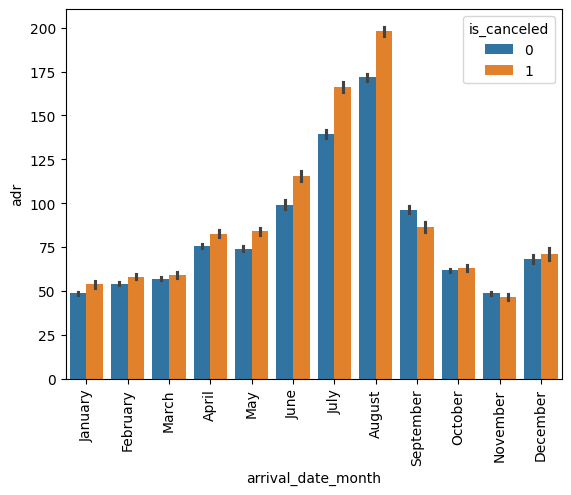

In [47]:
sns.barplot(x='arrival_date_month',y='adr',data=data ,hue='is_canceled')
plt.xticks(rotation='vertical')
plt.show()

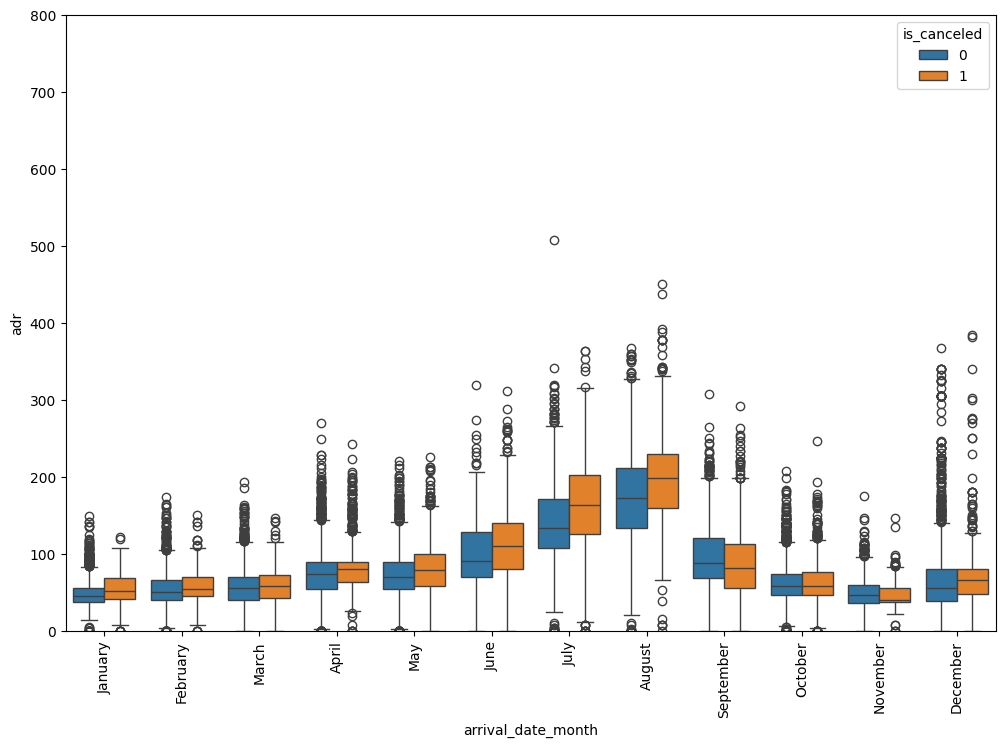

In [48]:
plt.figure(figsize=(12,8))
sns.boxplot(x='arrival_date_month',y='adr',data=data ,hue='is_canceled')
plt.xticks(rotation='vertical')


plt.ylim(0,800)
plt.show()

In [49]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [50]:
### Lets create a relationship table..
pd.crosstab(index=data['stays_in_weekend_nights'],columns=data['stays_in_week_nights'])

stays_in_week_nights,0,1,2,3,4,5,6,7,8,9,...,22,24,25,26,30,32,33,40,42,50
stays_in_weekend_nights,,,,,,,,,,,,,,,,,,,,,
0,365,5654,3403,2346,1127,312,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1640,1907,1800,1744,901,549,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,506,1130,1485,1297,1065,5821,537,295,246,41,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,171,205,272,82,38,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,53,258,143,89,53,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [51]:
## lets define our own function :

def week_function(row):
    feature1='stays_in_weekend_nights'
    feature2='stays_in_week_nights'

    if row[feature2]==0 and row[feature1] >0 :
        return 'stay_just_weekend'

    elif row[feature2]>0 and row[feature1] ==0 :
        return 'stay_just_weekdays'

    elif row[feature2]>0 and row[feature1] >0 :
        return 'stay_both_weekdays_weekends'

    else:
        return 'undefined_data'

In [52]:
data2['weekend_or_weekday']=data2.apply(week_function,axis=1)

In [53]:
data2.head(2)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,weekend_or_weekday
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0,Transient,0.0,0,0,Check-Out,7/1/2015,undefined_data
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0,Transient,0.0,0,0,Check-Out,7/1/2015,undefined_data


In [54]:
data2['weekend_or_weekday'].value_counts()

,count
weekend_or_weekday,
stay_both_weekdays_weekends,13745
stay_just_weekdays,9609
stay_just_weekend,1725
undefined_data,355


In [55]:
type(sd)

module

In [56]:
data2=sd.Sort_Dataframeby_Month(data2,'arrival_date_month')

In [57]:
data2.groupby(['arrival_date_month','weekend_or_weekday']).size()

arrival_date_month  weekend_or_weekday         
April               stay_both_weekdays_weekends    1495
                    stay_just_weekdays              898
                    stay_just_weekend               137
                    undefined_data                   20
August              stay_both_weekdays_weekends    1597
                    stay_just_weekdays              467
                    stay_just_weekend               114
                    undefined_data                   30
December            stay_both_weekdays_weekends     808
                    stay_just_weekdays             1007
                    stay_just_weekend               147
                    undefined_data                   52
February            stay_both_weekdays_weekends    1002
                    stay_just_weekdays             1089
                    stay_just_weekend               197
                    undefined_data                   20
January             stay_both_weekdays_weekends     649
                    stay_just_weekdays              990
                    stay_just_weekend               196
                    undefined_data                   31
July                stay_both_weekdays_weekends    1467
                    stay_just_weekdays              527
                    stay_just_weekend                83
                    undefined_data                   30
June                stay_both_weekdays_weekends     690
                    stay_just_weekdays              310
                    stay_just_weekend                56
                    undefined_data                   24
March               stay_both_weekdays_weekends    1162
                    stay_just_weekdays             1227
                    stay_just_weekend               154
                    undefined_data                   28
May                 stay_both_weekdays_weekends    1158
                    stay_just_weekdays              682
                    stay_just_weekend               200
                    undefined_data                   38
November            stay_both_weekdays_weekends     855
                    stay_just_weekdays              959
                    stay_just_weekend               129
                    undefined_data                   32
October             stay_both_weekdays_weekends    1405
                    stay_just_weekdays              899
                    stay_just_weekend               229
                    undefined_data                   42
September           stay_both_weekdays_weekends    1457
                    stay_just_weekdays              554
                    stay_just_weekend                83
                    undefined_data                    8
dtype: int64

In [58]:
group_data=data2.groupby(['arrival_date_month','weekend_or_weekday']).size().unstack().reset_index()

In [59]:
sorted_data=sd.Sort_Dataframeby_Month(group_data,'arrival_date_month')

In [60]:
sorted_data.set_index('arrival_date_month',inplace=True)

In [61]:
sorted_data

,stay_both_weekdays_weekends,stay_just_weekdays,stay_just_weekend,undefined_data
arrival_date_month,,,,
January,649,990,196,31
February,1002,1089,197,20
March,1162,1227,154,28
April,1495,898,137,20
May,1158,682,200,38
June,690,310,56,24
July,1467,527,83,30
August,1597,467,114,30
September,1457,554,83,8


<Axes: xlabel='arrival_date_month'>

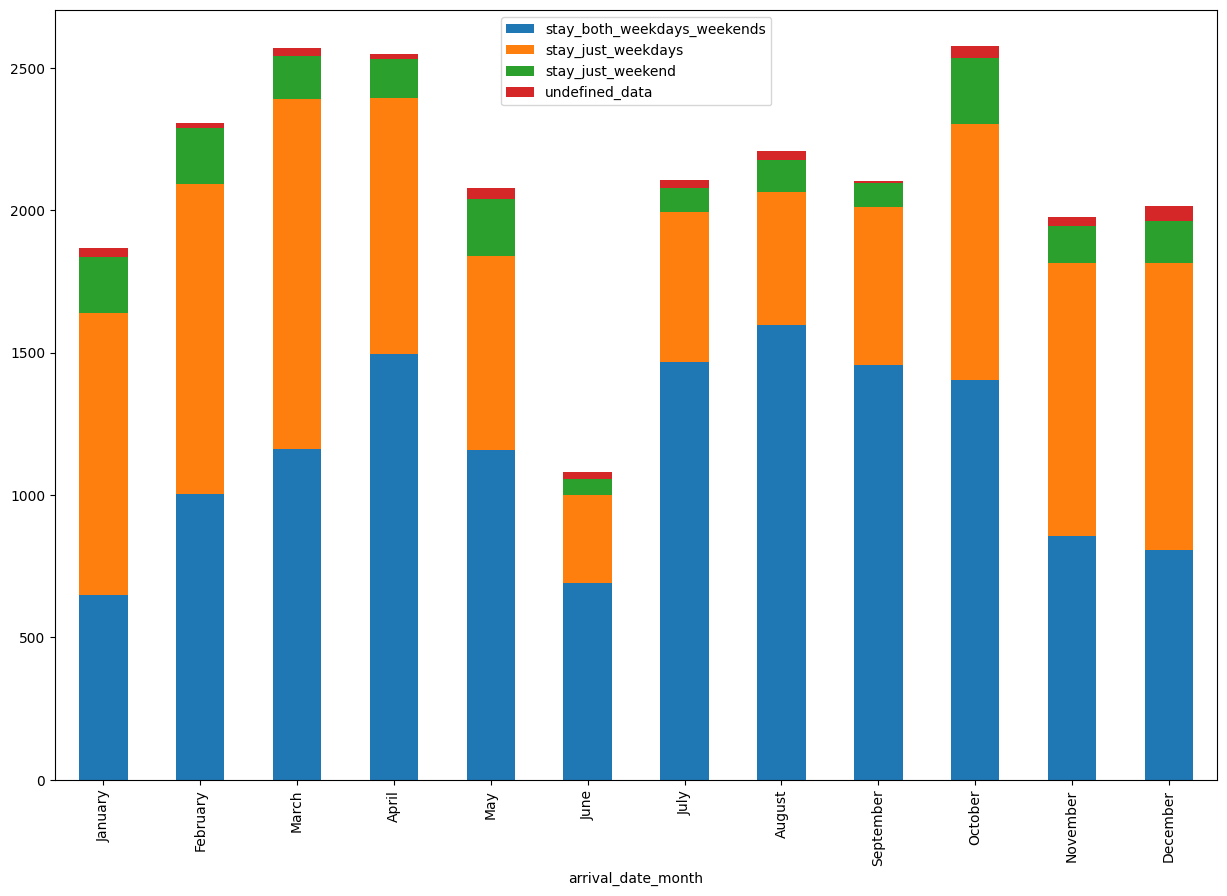

In [62]:
sorted_data.plot(kind='bar',stacked=True,figsize=(15,10))

In [63]:
data2.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'weekend_or_weekday'],
      dtype='object')

In [64]:
def family(row):
    if (row['adults']>0) &  (row['children']>0 or row['babies']>0) :
        return 1
    else:
        return 0

In [65]:
data['is_family']=data.apply(family,axis=1)

In [66]:
data['total_customer'] = data['adults'] + data['babies'] + data['children']

In [67]:
data['total_nights']=data['stays_in_week_nights'] + data['stays_in_weekend_nights']

In [68]:
data.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,is_family,total_customer,total_nights
0,Resort Hotel,0,109,2016,January,1,1,0,1,2,...,0,Transient-Party,59.94,0,1,Check-Out,1/2/2016,0,2,1
1,Resort Hotel,0,109,2016,January,1,1,0,1,2,...,0,Transient-Party,116.10,1,1,Check-Out,1/2/2016,1,4,1
2,Resort Hotel,1,2,2016,January,1,1,0,1,2,...,0,Transient,89.00,0,1,No-Show,1/1/2016,0,2,1


In [69]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'is_family',
       'total_customer', 'total_nights'],
      dtype='object')

In [70]:
data['deposit_type'].unique()

array(['No Deposit', 'Non Refund', 'Refundable'], dtype=object)

In [71]:
dict1={'No Deposit':0, 'Non Refund':1, 'Refundable': 0}

In [72]:
data['deposit_given']=data['deposit_type'].map(dict1)

In [73]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'is_family',
       'total_customer', 'total_nights', 'deposit_given'],
      dtype='object')

In [74]:
data.drop(columns=['adults', 'children', 'babies', 'deposit_type'],axis=1,inplace=True)

In [75]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'meal', 'country', 'market_segment',
       'distribution_channel', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'days_in_waiting_list',
       'customer_type', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'reservation_status',
       'reservation_status_date', 'is_family', 'total_customer',
       'total_nights', 'deposit_given'],
      dtype='object')